In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("/content/customer_support_tickets_200k.csv", on_bad_lines="skip")

print(df.shape)
df.head()

(11409, 30)


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4.0,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2.0,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4.0,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7.0,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3.0,Corporate


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11409 entries, 0 to 11408
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    11409 non-null  int64  
 1   customer_name                11409 non-null  object 
 2   customer_email               11409 non-null  object 
 3   product                      11409 non-null  object 
 4   category                     11409 non-null  object 
 5   issue_description            11409 non-null  object 
 6   resolution_notes             11408 non-null  object 
 7   priority                     11408 non-null  object 
 8   status                       11408 non-null  object 
 9   channel                      11408 non-null  object 
 10  region                       11408 non-null  object 
 11  customer_age                 11408 non-null  float64
 12  customer_gender              11408 non-null  object 
 13  subscription_typ

In [8]:
df.isnull().sum()

,0
ticket_id,0
customer_name,0
customer_email,0
product,0
category,0
issue_description,0
resolution_notes,1
priority,1
status,1
channel,1


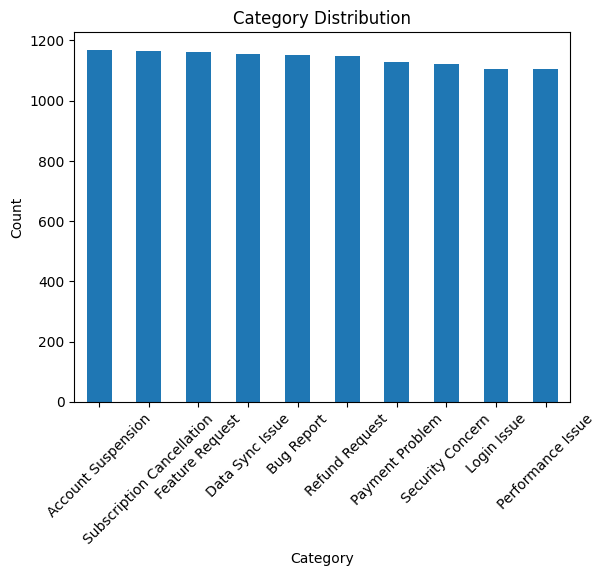

In [9]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [10]:
df['category'].value_counts().head(10)

,count
category,
Account Suspension,1169
Subscription Cancellation,1165
Feature Request,1162
Data Sync Issue,1156
Bug Report,1150
Refund Request,1148
Payment Problem,1127
Security Concern,1123
Login Issue,1105


In [11]:
cols = [
    'issue_description',
    'category',
    'priority',
    'channel',
    'product',
    'language',
    'customer_segment',
    'issue_complexity_score',
    'resolution_time_hours',
    'customer_satisfaction_score'
]

df_clean = df[cols].copy()
df_clean.head()

,issue_description,category,priority,channel,product,language,customer_segment,issue_complexity_score,resolution_time_hours,customer_satisfaction_score
0,The payment was deducted from my bank account ...,Account Suspension,Urgent,Email,Web Portal,French,Small Business,4.0,108.36,5.0
1,I found a bug in the latest update affecting r...,Performance Issue,Urgent,Email,Mobile App,English,Small Business,2.0,87.43,5.0
2,The application crashes whenever I try to uplo...,Performance Issue,Medium,Chat,Web Portal,French,Corporate,4.0,78.50,5.0
3,My subscription was cancelled without my reque...,Subscription Cancellation,Medium,Social Media,Payment Gateway,Spanish,Corporate,7.0,239.36,4.0
4,The system is not syncing data across devices ...,Feature Request,High,Email,Web Portal,Spanish,Corporate,3.0,122.34,5.0


In [12]:
df.groupby(['category', 'priority']).size().unstack().fillna(0)

priority,High,Low,Medium,Urgent
category,,,,
Account Suspension,281,300,303,285
Bug Report,294,309,270,277
Data Sync Issue,294,283,298,281
Feature Request,265,315,268,313
Login Issue,287,258,259,301
Payment Problem,263,277,278,309
Performance Issue,273,282,294,255
Refund Request,274,286,297,291
Security Concern,285,284,270,284


In [13]:
df.groupby(['category', 'channel']).size().unstack().fillna(0)

channel,Chat,Email,Phone,Social Media,Web Form
category,,,,,
Account Suspension,216,232,243,219,259
Bug Report,227,223,241,214,245
Data Sync Issue,230,229,259,238,200
Feature Request,215,261,219,219,247
Login Issue,200,249,215,213,228
Payment Problem,214,240,208,231,234
Performance Issue,227,211,191,241,234
Refund Request,238,223,220,228,239
Security Concern,202,234,248,216,223


In [14]:
df['language'].value_counts()

,count
language,
English,1950
French,1924
Chinese,1906
Spanish,1886
Japanese,1872
German,1870


In [15]:
df.groupby('category')['issue_complexity_score'].mean().sort_values(ascending=False)

,issue_complexity_score
category,
Data Sync Issue,5.610727
Account Suspension,5.579127
Performance Issue,5.552536
Payment Problem,5.543922
Security Concern,5.536064
Login Issue,5.532127
Refund Request,5.522648
Subscription Cancellation,5.455794
Feature Request,5.449612


In [16]:
df.groupby('category')['resolution_time_hours'].mean().sort_values(ascending=False)

,resolution_time_hours
category,
Login Issue,122.706516
Subscription Cancellation,122.173871
Refund Request,121.575801
Data Sync Issue,121.470744
Feature Request,121.435142
Performance Issue,121.359293
Payment Problem,119.919281
Account Suspension,119.878802
Security Concern,118.892582


In [17]:
df.groupby('category')['customer_satisfaction_score'].mean().sort_values()

,customer_satisfaction_score
category,
Login Issue,2.922172
Subscription Cancellation,2.951073
Data Sync Issue,2.987889
Feature Request,2.995693
Payment Problem,3.015972
Refund Request,3.023519
Account Suspension,3.030796
Bug Report,3.053913
Security Concern,3.061443


In [18]:
df_rag = df[['issue_description', 'category']].dropna().copy()
labels = sorted(df_rag['category'].unique().tolist())

In [30]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [33]:

embeddings = embedder.encode(
    df_rag['issue_description'].tolist(),
    show_progress_bar=True
)

df_rag['embedding'] = list(embeddings)

Batches:   0%|          | 0/357 [00:00<?, ?it/s]

In [20]:
import numpy as np

def retrieve_similar(query, top_k=3):
    q_vec = embedder.encode(query)

    emb_matrix = np.vstack(df_rag['embedding'].values)

    sims = np.dot(emb_matrix, q_vec) / (
        np.linalg.norm(emb_matrix, axis=1) * np.linalg.norm(q_vec)
    )

    top_idx = sims.argsort()[-top_k:][::-1]

    return df_rag.iloc[top_idx]

In [21]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [22]:
def build_rag_prompt(text):
    examples = retrieve_similar(text)

    context = ""
    for _, row in examples.iterrows():
        context += f"""
Ticket: {row['issue_description']}
Category: {row['category']}
"""

    return f"""
You are a strict classifier for customer support tickets.

Use the examples below:

{context}

Now classify this ticket:
{text}

Rules:
- Output ONLY ONE category
- Must be exactly from allowed categories
- No explanation

Answer:
"""

In [23]:
def llm_predict(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [24]:
def rag_llm_predict(text):
    prompt = build_rag_prompt(text)
    return llm_predict(prompt)

In [25]:
model_name = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [26]:
from sklearn.model_selection import train_test_split

test_data = df_rag[['issue_description', 'category']].sample(1000, random_state=42)

In [28]:
def predict_rag(text):
    output = rag_llm_predict(text)

    for label in labels:
        if label.lower() in output.lower():
            return label

    return "Unknown"

In [ ]:
y_true = []
y_pred = []

for _, row in test_data.iterrows():
    y_true.append(row['category'])
    y_pred.append(predict_rag(row['issue_description']))

In [ ]:
from sklearn.metrics import accuracy_score

print("RAG Accuracy:", accuracy_score(y_true, y_pred))